In [116]:
import os
os.environ['TMPDIR'] = '/scratch3/users/michalinamm'

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import emcee
import os
import glob
import pickle
import copy
import time
import cv2
from scipy import special
from numpy import loadtxt

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from pdf2image import convert_from_path
import corner

from astropy.io import fits  # We use fits to open the actual data file
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
from astropy.visualization import make_lupton_rgb
from astropy.stats import sigma_clipped_stats, sigma_clip
from photutils.aperture import CircularAperture, RectangularAperture
from astropy import units as u 
from astrocut import FITSCutout
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import radio_beam
from radio_beam import Beam
from spectral_cube import SpectralCube


def sky_coord_in_deg_from_pix(x_pix_coord,y_pix_coord,wcs):
    skycoord = SkyCoord.from_pixel(xp=x_pix_coord,yp=y_pix_coord, wcs=wcs)
    RA = skycoord.ra.degree
    DEC = skycoord.dec.degree
    return RA, DEC

# get frequency form channel
def channel_to_frequency(channel,wave0,wavedelta,channel0):
    frequency = wave0+wavedelta*(channel-channel0)
    return frequency

def gauss(x, H, A, x0, sigma): 
            return H + A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))


def ini_plot(x_pix_coord,y_pix_coord,ra,dec,source_ID):
    #prepare the figure and its layout
    fig = plt.figure(figsize=(8,8*11.5/10))
    gs = fig.add_gridspec(5,11, hspace=0, wspace=0,height_ratios = [2,1,5,0.01,3],width_ratios = [1,1,1,1,1,0.1,1,1,1,1,1])
    axs = gs.subplots(sharex=True, sharey=True)

    for ax in axs[0, 0:11]:
        ax.remove()
    axcoordinfo = fig.add_subplot(gs[0, 0:3])
    axspecfitinfo = fig.add_subplot(gs[0, 3:6])
    axflaginfo = fig.add_subplot(gs[0, 6:11])

    for ax in axs[1, 0:]:
        ax.remove() 
    for ax in axs[2, 0:5]:
        ax.remove()

    wcs_radio_image = WCS(naxis=2)
    wcs_radio_image.wcs.crpix = [data_cube_wcs.wcs.crpix[0]-(x_pix_coord-image_pixel_width/2), data_cube_wcs.wcs.crpix[1]-(y_pix_coord-image_pixel_width/2)]
    wcs_radio_image.wcs.crval = [data_cube_wcs.wcs.crval[0], data_cube_wcs.wcs.crval[1]]
    wcs_radio_image.wcs.cunit = [data_cube_wcs.wcs.cunit[0], data_cube_wcs.wcs.cunit[1]]
    wcs_radio_image.wcs.ctype = [data_cube_wcs.wcs.ctype[0], data_cube_wcs.wcs.ctype[1]]
    wcs_radio_image.wcs.cdelt = [data_cube_wcs.wcs.cdelt[0], data_cube_wcs.wcs.cdelt[1]]

    axradioimage = fig.add_subplot(gs[2, 0:5],projection=wcs_radio_image)

    try:
        file_g = glob.glob(path_to_optical_images+'/HSC_images_R/*%s*.fits'%(source_ID))[0]
        g=fits.open(file_g)
        wcs_vis = WCS(g[1].header)
        ra = round(ra,4)
        dec = round(dec,4)
        width_arc = round(image_arc_width,6)
        
        center_coord = SkyCoord(ra,dec, unit="deg")
        cutout_size = [width_arc/wcs_vis.wcs.cd[1][1]/3600, width_arc/3600/wcs_vis.wcs.cd[1][1]]
        output_files = FITSCutout(input_files=[file_g],
                                 coordinates=center_coord,
                                 cutout_size=cutout_size,
                                 single_outfile=False)
        wcs_vis = WCS(output_files.fits_cutouts[0][1].header)
    except: wcs_vis = wcs_radio_image

            
    for ax in axs[2, 5:]:
        ax.remove()
    axvisimage = fig.add_subplot(gs[2, 6:],projection=wcs_vis)

    for ax in axs[3, 0:]:
        ax.remove() 

    for ax in axs[4, 0:]:
        ax.remove()
    axspectrumwide = fig.add_subplot(gs[4, 0:])

    
    # set ticks and labels
    axflaginfo.set_xticks([])
    axflaginfo.set_yticks([])
    axspecfitinfo.set_xticks([])
    axspecfitinfo.set_yticks([])
    axcoordinfo.set_xticks([])
    axcoordinfo.set_yticks([])

    axvisimage.set_title('optical image [deg] \n \n \n')
    axradioimage.set_title('radio moment 0 map [deg] \n \n \n')
    axspectrumwide.set_xlabel('Frequency [MHz]')
    axspectrumwide.set_ylabel('Beam Integrated Flux [Jy Hz]')
    axspectrumwide.xaxis.set_minor_locator(AutoMinorLocator())
    axspectrumwide.yaxis.set_minor_locator(AutoMinorLocator())

    
    ra_axis = axvisimage.coords[0]
    dec_axis = axvisimage.coords[1]

    ra_axis.set_major_formatter('d.ddd')
    dec_axis.set_major_formatter('d.ddd')

    ra_axis.set_ticks(number=4)
    dec_axis.set_ticks(number=4)

    ra_axis.set_axislabel('RA [deg]')
    dec_axis.set_axislabel('DEC [deg]')

    dec_axis.set_ticks_position('r')
    dec_axis.set_ticklabel_position('r')
    dec_axis.set_axislabel_position('r')
    ra_axis.set_ticks_position('t')
    ra_axis.set_ticklabel_position('t')
    ra_axis.set_axislabel_position('t')

    ra_axis = axradioimage.coords[0]
    dec_axis = axradioimage.coords[1]

    ra_axis.set_major_formatter('d.ddd')
    dec_axis.set_major_formatter('d.ddd')

    ra_axis.set_ticks(number=4)
    dec_axis.set_ticks(number=4)

    ra_axis.set_axislabel('RA [deg]')
    dec_axis.set_axislabel('DEC [deg]')

    dec_axis.set_ticks_position('l')
    dec_axis.set_ticklabel_position('l')
    dec_axis.set_axislabel_position('l')
    ra_axis.set_ticks_position('t')
    ra_axis.set_ticklabel_position('t')
    ra_axis.set_axislabel_position('t')

    return fig, axs, axflaginfo, axspecfitinfo, axcoordinfo, axradioimage, axvisimage, axspectrumwide

def get_beam_spectrum(x_coord,y_coord,beam_diameter,flux_cubelet_start,flux_cubelet_end):
    if flux_cubelet_start<0: flux_cubelet_start=0
    if flux_cubelet_end>cube_channel_range: flux_cubelet_end=cube_channel_range


    flux_cubelet = np.array(data_cube.unmasked_data[int(flux_cubelet_start):int(flux_cubelet_end),
                                                y_coord-int(beam_diameter/2):y_coord+int(beam_diameter/2),
                                                x_coord-int(beam_diameter/2):x_coord+int(beam_diameter/2)],dtype=np.float32)
    rows, cols = flux_cubelet.shape[1], flux_cubelet.shape[2]
    y, x = np.ogrid[:rows, :cols]
    center_row, center_col = (rows - 1) / 2, (cols - 1) / 2
    distance = np.sqrt((x - center_col)**2 + (y - center_row)**2)
    
    flux = np.ones(int(flux_cubelet_end-flux_cubelet_start))
    for channel in range(len(flux)):
        radius = int(beam_diameter/2)-1
        if radius<2.5: radius=2.5
        (flux_cubelet[channel])[distance>radius] = np.nan
        flux[channel] = np.nansum(flux_cubelet[channel])
    return flux
    
def channel_to_frequency(channel,wcs):
    wave0,wavedelta,channel0 = wcs.wcs.crval[2],wcs.wcs.cdelt[2],wcs.wcs.crpix[2]
    frequency = wave0+wavedelta*(channel-channel0)
    return frequency
    
def wide_spectrum_plot(axspectrumwide,wavelength_range_array_wide,x_coord,y_coord,beam_diameter,sources_dict,source,bmpix):
    
    # get flux for the contour mask
    flux = get_beam_spectrum(x_coord,y_coord,beam_diameter,wavelength_range_array_wide[0],wavelength_range_array_wide[-1]+1)

 
    # plot flux vs wavelength
    xdata = channel_to_frequency(wavelength_range_array_wide,data_cube_wcs)/1E6
    ydata = flux*bmpix*dfreq # flux in Jy Hz
    
    axspectrumwide.set_ylim((np.min(ydata)-0.1*np.absolute(np.max(ydata)-np.min(ydata))),np.max(ydata)+0.15*np.absolute(np.max(ydata)-np.min(ydata)))
    axspectrumwide.set_xlim(np.min(xdata),np.max(xdata))
  
    #axspectrumwide.step(xdata,ydata,color = 'black',alpha=0.45,lw=0.7)
    axspectrumwide.step(xdata,ydata,color = 'black',alpha=0.5,lw=0.75,label='spectrum')
    
    xdata = np.arange(wavelength_range_array_wide[0],wavelength_range_array_wide[-1]+1,0.2)
    axspectrumwide.plot(channel_to_frequency(xdata,data_cube_wcs)/1E6,bmpix*dfreq*gauss(xdata,sources_dict['H'].values[source],sources_dict['A'].values[source],sources_dict['x0'].values[source],sources_dict['sigma'].values[source],),color='blue',label='Gaussian function fit',lw=0.75,alpha=0.9)
    
    axspectrumwide.axvline(channel_to_frequency(sources_dict['x0'].values[source],data_cube_wcs)/1E6,color='gray',ls='--',alpha=0.2,lw=1)
    axspectrumwide.legend(loc='upper right')
    
    return ydata 


def hi_image_plot(x_coord,y_coord,wavelength_range_left,wavelength_range_right,axradioimage,beam_radius_pixel):
    
    # HI IMAGE
    # create moment zero map from channels defined by the wavelength range
    print(wavelength_range_left,wavelength_range_right)
    cubelet = np.array(data_cube.unmasked_data[wavelength_range_left : wavelength_range_right,
                                   int(y_coord-image_pixel_width/2):int(y_coord+image_pixel_width/2),
                                   int(x_coord-image_pixel_width/2):int(x_coord+image_pixel_width/2)],dtype=np.float32)
    
    moment_0 = np.nansum(cubelet,0)
    slit_image = np.array(moment_0)

    # plot the image
    axradioimage.imshow(slit_image,origin='lower')

    # plot the cross hair
    axradioimage.axvline((slit_image.shape[0]-1)/2+0.5,color='gray',ls='--',alpha=0.3)
    axradioimage.axhline((slit_image.shape[1]-1)/2+0.5,color='gray',ls='--',alpha=0.3)

    # plot beam
    circle1 = plt.Circle((slit_image.shape[0]/2, slit_image.shape[0]/2), slit_image.shape[0]/image_pixel_width*beam_radius_pixel, color='white',fill=False,ls='--')
    axradioimage.add_patch(circle1)


def optical_image_plot(axvisimage,source_ID,beam_radius_pixel):
    try:
        #try:
        ra = round(ra_array[source],4)
        dec = round(dec_array[source],4)
        width_arc = round(image_arc_width,6)
        
        file_g = glob.glob(path_to_optical_images+'/HSC_images_R/*%s*.fits'%(source_ID))[0]
        file_b = glob.glob(path_to_optical_images+'/HSC_images_G/*%s*.fits'%(source_ID))[0]
        file_r = glob.glob(path_to_optical_images+'/HSC_images_I/*%s*.fits'%(source_ID))[0]
        
        g=fits.open(file_g)
        wcs_vis = WCS(g[1].header)
        center_coord = SkyCoord(ra,dec, unit="deg")
        cutout_size = [width_arc/wcs_vis.wcs.cd[1][1]/3600, width_arc/3600/wcs_vis.wcs.cd[1][1]]

        output_files = FITSCutout(input_files=[file_g,file_b,file_r],
                                 coordinates=center_coord,
                                 cutout_size=cutout_size,
                                 single_outfile=False)
        r_image=np.sqrt(np.absolute(output_files.fits_cutouts[2][1].data))
        g_image=np.sqrt(np.absolute(output_files.fits_cutouts[0][1].data))
        b_image=np.sqrt(np.absolute(output_files.fits_cutouts[1][1].data))
        wcs_vis = WCS(output_files.fits_cutouts[2][1].header)
        
        min_r,min_b,min_g = np.min(r_image),np.min(b_image),np.min(g_image)
        max_r,max_b,max_g = np.max(r_image),np.max(b_image),np.max(g_image)
        
        
        rgb = make_lupton_rgb(r_image*0.9,g_image,b_image*1.3,Q=2.5,stretch=1.1)
        axvisimage.imshow(rgb,origin='lower')

        # mark beam
        circle1 = plt.Circle((r_image.shape[0]/2, r_image.shape[0]/2), r_image.shape[0]/image_pixel_width*beam_radius_pixel, color='white',fill=False,ls='--')
        axvisimage.add_patch(circle1)
            
    
        # plot the cross hair
        axvisimage.axvline((rgb.shape[0]-1)/2,color='gray',ls='--',alpha=0.3)
        axvisimage.axhline((rgb.shape[1]-1)/2,color='gray',ls='--',alpha=0.3)
        
    except:
        axvisimage.imshow(np.zeros((image_pixel_width,image_pixel_width)))
        axvisimage.annotate('optical image not plotted',(0.25*image_pixel_width,image_pixel_width/2),color = 'white')



def info_about_target(source_dict,source,axflaginfo, axspecfitinfo, axcoordinfo,beam_diameter):
    # coordinates
    
    axcoordinfo.text(0.03,0.9,'DETECTION COORDINATES')
    axcoordinfo.text(0.03,0.75,'xpix ypix channel: '+str(source_dict['x_coord'].values[source])+' '+str(source_dict['y_coord'].values[source])+' '+str(round(source_dict['x0'].values[source])))
    sky_coords = SkyCoord(source_dict['RA_deg'].values[source],source_dict['Dec_deg'].values[source], frame="fk5", unit="deg")

    if sky_coords.dec.dms.d<0: zero_non_zero = '-'
    else: zero_non_zero='+'
    hex_coords = str(int(sky_coords.ra.hms.h)).zfill(2)+'h'+str(int(sky_coords.ra.hms.m)).zfill(2)+'m'+str(round(sky_coords.ra.hms.s,1)).zfill(4)+'s '+zero_non_zero+str(int(abs(sky_coords.dec.dms.d))).zfill(2)+'d'+str(int(abs(sky_coords.dec.dms.m))).zfill(2)+'m'+str(int(round(abs(sky_coords.dec.dms.s)))).zfill(2)+'s'
    axcoordinfo.text(0.03,0.60,'deg: '+str(round(source_dict['RA_deg'].values[source],5))+' '+str(round(source_dict['Dec_deg'].values[source],5)))
    axcoordinfo.text(0.03,0.50,'hex: '+hex_coords)
    axcoordinfo.text(0.03,0.40,  'frequency: '+str(round(source_dict['frequency_Hz'].values[source]/1E6,2))+' [MHz]')
    
    redshifthi = (1420 - source_dict['frequency_Hz'].values[source]/1E6)/(source_dict['frequency_Hz'].values[source]/1E6)
    redshiftoh = (1665 - source_dict['frequency_Hz'].values[source]/1E6)/(source_dict['frequency_Hz'].values[source]/1E6)
    
    axcoordinfo.text(0.03,0.30,  'redshift:   HI: '+str(round(redshifthi,3))+'  OH: '+str(round(redshiftoh,3)))
    axcoordinfo.text(0.03,0.05,  'beam diameter: '+str(round(beam_diameter,2))+' arcsec')
    
    # spectral fitting
    axspecfitinfo.text(0.03,0.9,'SNR AND GAUSSIAN FIT')

    axspecfitinfo.text(0.03,0.75,r'SNR$_{intim}$ = '+str(round(source_dict['int_SNR'].values[source],3)))
    axspecfitinfo.text(0.03,0.65,r'SNR$_{spectral}$ = '+str(round(source_dict['spectral_SNR'].values[source],3)))
    axspecfitinfo.text(0.03,0.55,r'R$^{2}$ = '+str(round(source_dict['rsqr'].values[source],3)))

    axspecfitinfo.text(0.03,0.40,r'x$_{0}$ = '+str(round(source_dict['x0'].values[source],3)))
    axspecfitinfo.text(0.03,0.30,'σ = '+str(round(source_dict['sigma'].values[source],3)))
    axspecfitinfo.text(0.03,0.20,'A = '+str(round(source_dict['A'].values[source],3)))
    axspecfitinfo.text(0.03,0.10,'H = '+str(round(source_dict['H'].values[source],3)))

    
    
    axflaginfo.text(0.03,0.9,'CROSSMATCH')


def read_in_radio_file(radio_file):
    
    # get cube data
    data_cube = SpectralCube.read(radio_file)
    # wcs
    data_cube_wcs = data_cube.wcs
    # channel range
    cube_channel_range = data_cube.shape[0]
    
    
    # create 2D WCS object
    data_cube_wcs_2d = WCS(naxis=2)
    data_cube_wcs_2d.wcs.crpix = [data_cube_wcs.wcs.crpix[0], data_cube_wcs.wcs.crpix[1]]
    data_cube_wcs_2d.wcs.crval = [data_cube_wcs.wcs.crval[0], data_cube_wcs.wcs.crval[1]]
    data_cube_wcs_2d.wcs.cunit = [data_cube_wcs.wcs.cunit[0], data_cube_wcs.wcs.cunit[1]]
    data_cube_wcs_2d.wcs.ctype = [data_cube_wcs.wcs.ctype[0], data_cube_wcs.wcs.ctype[1]]
    data_cube_wcs_2d.wcs.cdelt = [data_cube_wcs.wcs.cdelt[0], data_cube_wcs.wcs.cdelt[1]]
            
    
    return data_cube,data_cube_wcs,data_cube_wcs_2d,cube_channel_range





In [117]:
###### CONTROL PANEL##########################
perform_spectral_fit = False
plot_optical_image=True
download_optical_images = True

image_arc_width = 60
spectrum_length = 200

path_to_optical_images = "./data"
#############################################################

# data arrays
path_to_results = "./results_L2/"
sources_dict_full = pd.read_csv('./results_L2/found_sources.csv')

# data cube
radio_file = "/idia/projects/mightee/mightee-hi/DR1_COSMOS/MIGHTEE-HI_DR1_L2_r0p5/MIGHTEE-HI_DR1_COSMOS_L2_r0p5_clean_conv_3001-4055.fits"
data_cube,data_cube_wcs,data_cube_wcs_2d,cube_channel_range=read_in_radio_file(radio_file)

#plot params
plt.rcParams.update({'font.size': 7})
from matplotlib.backends.backend_pdf import PdfPages

# some useful constants
restfr=1.420405*10**9 #HI rest frequency in HZ 
H0=70 #Hubble constant
c=299792 #speed of light in km/s

source:  0  out of  64
beam diameter:  15.768
beamradius:  3.942
0 3


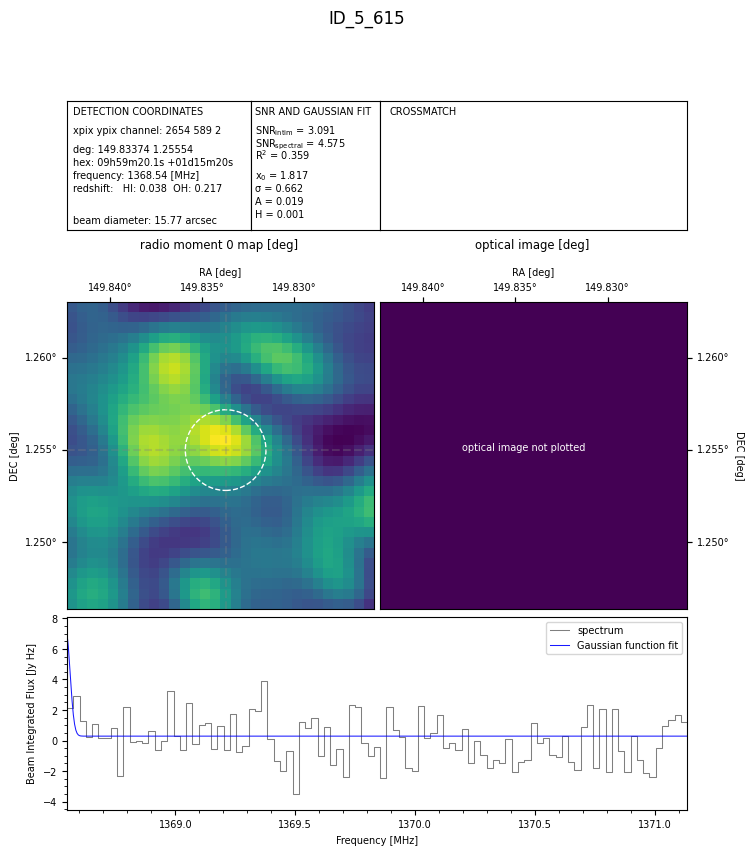

source:  1  out of  64
beam diameter:  15.768
beamradius:  3.942
0 8


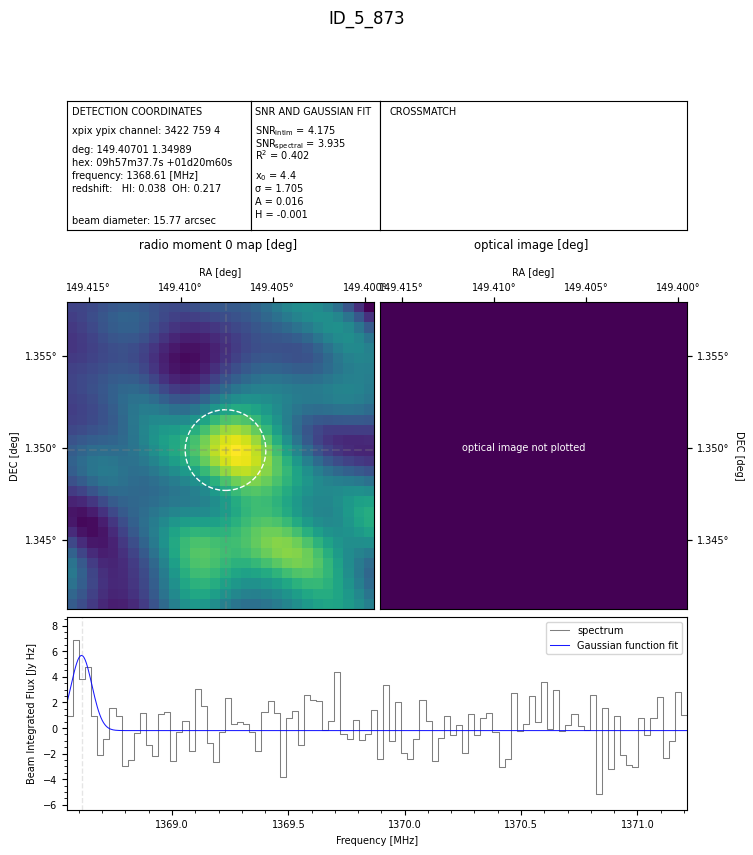

source:  2  out of  64
beam diameter:  15.768
beamradius:  3.942
0 6


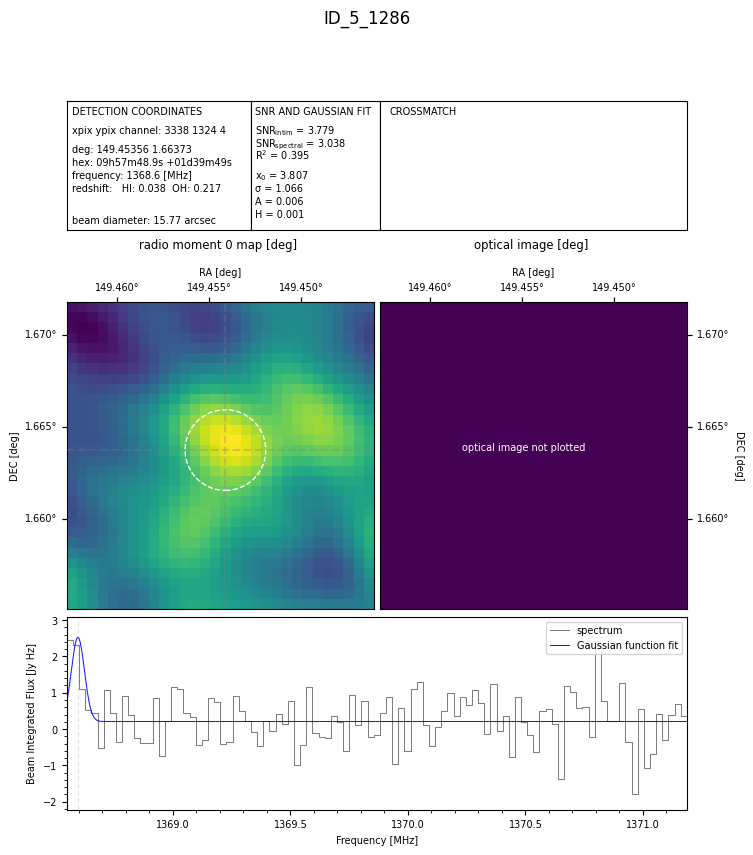

source:  3  out of  64
beam diameter:  15.768
beamradius:  3.942
0 16


KeyboardInterrupt: 

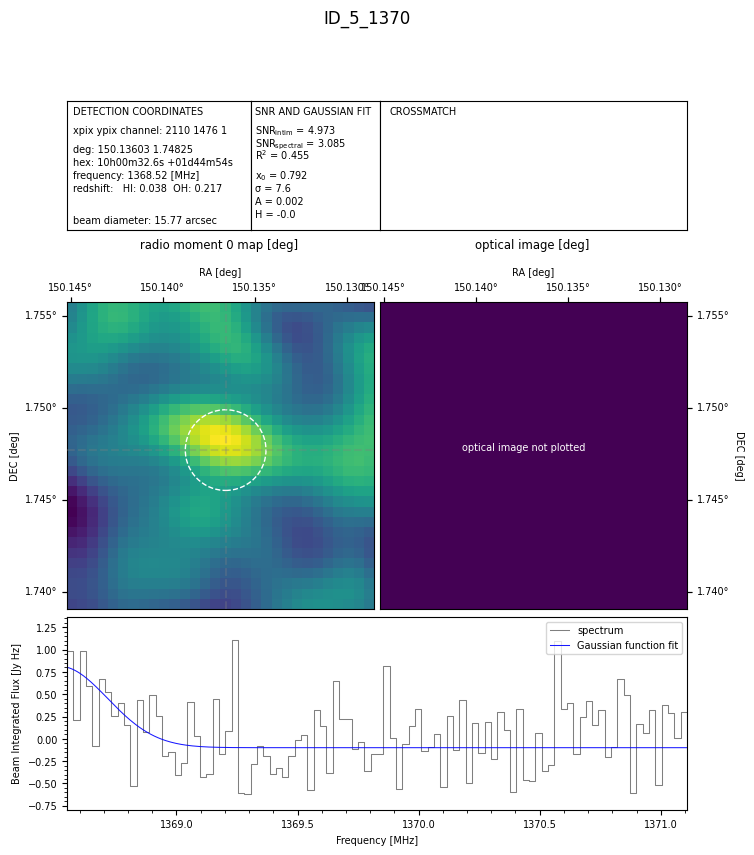

In [119]:
def make_detection_plot(sources_dict):
    for source in range(len(sources_dict)):
        print('source: ',source,' out of ',len(sources_dict))
        # data coordinates
        ra, dec = (sources_dict['RA_deg'].values)[source], (sources_dict['Dec_deg'].values)[source]
        z_channel, sigma =  (sources_dict['x0'].values)[source], ((sources_dict['sigma'].values)[source])
        
        sky_coords =SkyCoord(ra, dec, unit="deg",frame="fk5")
        x_pix_coord, y_pix_coord = skycoord_to_pixel(sky_coords,data_cube_wcs)
        x_pix_coord,y_pix_coord,z_channel  = int(x_pix_coord),int(y_pix_coord),int(z_channel)
        
        image_pixel_width = int(np.array(image_arc_width/( np.abs(data_cube_wcs.wcs.cdelt[0])*3600) ))
        if np.mod(image_pixel_width,2)!=0: image_pixel_width=image_pixel_width+1

        # spectrum range
        wavelength_range_left, wavelength_range_right = int(z_channel-spectrum_length/2), int(z_channel+spectrum_length/2)
        if wavelength_range_left<0: wavelength_range_left=2
        if wavelength_range_right>= cube_channel_range : wavelength_range_right = cube_channel_range -2
        wavelength_range_array = np.arange(wavelength_range_left,wavelength_range_right+1,1,dtype=int)
        
        # beam diameter
        if beam==None:
            try:
                beams_arc_diameter_array = data_cube.beams.major.value
            except: 
                try:
                    beams_arc_diameter_array = np.ones(len(data_cube.beam.value)) * data_cube.beam.major.value
                except: 
                    print('SpectralCube failed to read the beam data, use "beam" argument to specify the beam diameter manually.')
        else:
            beams_arc_diameter_array = np.ones(cube_channel_range)*beam

            
        beam_diameter_arc = np.median(beams_arc_diameter_array[wavelength_range_left:wavelength_range_right])
        print('beam diameter: ',beam_diameter_arc)
        beam_radius_pixel = np.abs(round(beam_diameter_arc/2/np.abs(data_cube_wcs.wcs.cdelt[0]*3600),3))
        print('beamradius: ',beam_radius_pixel)
    
        dpix=np.abs(data_cube_wcs.wcs.cdelt[0])*3600 # width of pixel in arcsec
        dfreq=np.abs(data_cube_wcs.wcs.cdelt[2]) # width of channel in Hz
        omega = np.pi*beam_diameter_arc**2/(4*np.log(2)) # beam area in arcsec
        bmpix=dpix**2/omega
    
        # MAKE THE PLOT
        params = {'mathtext.default': 'regular' }          
        plt.rcParams.update(params)
            
        # initialize the plot
        fig, axs, axflaginfo, axspecfitinfo, axcoordinfo, axradioimage, axvisimage, axspectrumwide = ini_plot(x_pix_coord,y_pix_coord,ra,dec,sources_dict['ID'].values[source])  
    
        # plot optical image
        optical_image_plot(axvisimage,source,beam_radius_pixel)
        
        # plot HI image
        left_channel = int(np.floor(z_channel-2*sigma))
        right_channel = int(np.ceil(z_channel+2*sigma))

        if left_channel<0: left_channel=0
        if right_channel>cube_channel_range: right_channel=cube_channel_range

        hi_image_plot(x_pix_coord,y_pix_coord, left_channel, right_channel,axradioimage,beam_radius_pixel)
    
        # INFO ABOUT TARGET
        info_about_target(sources_dict,source,axflaginfo, axspecfitinfo, axcoordinfo,beam_diameter_arc) 
        
        
        # plot wide spectrum
        flux = wide_spectrum_plot(axspectrumwide,wavelength_range_array,x_pix_coord,y_pix_coord,beam_diameter_arc/np.abs(data_cube_wcs.wcs.cdelt[0]*3600),sources_dict,source,bmpix)
        
    
        fig.suptitle(sources_dict['ID'].values[source],fontsize=12)
        
    
    
        # save the figures
        newpath = path_to_results +'detection_plots' 
        if not os.path.exists(newpath):
            os.makedirs(newpath)
            
        out_file = path_to_results+'detection_plots/'+sources_dict['ID'].values[source]+'.pdf'
        fig.savefig(out_file,bbox_inches='tight')
        plt.show()
        #except: print('fail')

make_detection_plot(sources_dict_full)

